# Model Prediktif Mesin Bubut (BBT-001) — Hybrid DNN-SVM

Pipeline: sensor -> DNN (feature extractor) -> SVM (classifier), dengan SMOTE untuk menangani class imbalance, serta SHAP & LIME untuk explainability. Struktur mengikuti `induksi_model.ipynb`, `forging_model.ipynb`, dan `bor_model.ipynb` yang sudah divalidasi.

Dataset: `dataset-mesin-bubut-augmented-6000.csv` (6.000 baris) berisi 6 sensor — daya aktif total, suhu, getaran 3 sumbu (X, Y, Z), dan `Vrms` (getaran resultan).

Dua catatan khas dataset ini yang membedakannya dari mesin lain:

1. **Data hasil augmentasi.** Kolom `sumber` membedakan baris `asli` (420 baris pengukuran) dari `sintetis` (5.580 baris turunan), dan kolom `id_induk` menandai baris asli mana yang menjadi induk tiap baris sintetis. Karena itu pemisahan train/val/test **dilakukan per `id_induk`**, bukan per baris — kalau dipisah per baris, turunan sintetis dari induk yang sama bisa jatuh di train sekaligus di test, dan skor evaluasi jadi terlalu optimis (kebocoran data akibat augmentasi).
2. **Kelas sudah seimbang** (3.000 `normal` : 3.000 `rusak`), sehingga SMOTE praktis tidak menambah sampel sintetis. Langkah ini tetap dipertahankan agar pipeline identik dengan mesin lain — bila di kemudian hari data lapangan yang masuk tidak seimbang, penanganannya sudah tersedia. ADASYN tidak dipakai dengan alasan yang sama seperti mesin Induksi, Forging, dan Bor: kelas minoritas terpisah cukup jauh pada sensor getaran sehingga perhitungan rasio kepadatan tetangga berisiko gagal.

In [1]:
%matplotlib inline

import random
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential

import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [2]:
raw = pd.read_csv("dataset-mesin-bubut-augmented-6000.csv")
print("Kolom asli:", list(raw.columns))

# Nama kolom asli memakai label tampilan berbahasa Indonesia beserta satuannya
# (dan simbol derajat pada kolom suhu). Diseragamkan ke snake_case agar konsisten
# dengan model mesin lain (Induksi memakai `temp_c`; Forging & Bor memakai
# `vx`, `vy`, `vz`) sekaligus aman dipakai sebagai key JSON payload sensor di
# backend. Pencocokan memakai kata kunci, bukan string persis, supaya tidak
# gampang patah kalau file dibaca dengan encoding berbeda.
COLUMN_KEYWORDS = [
    ("active power", "active_power_w"),
    ("suhu",         "temp_c"),
    ("sumbu x",      "vx"),
    ("sumbu y",      "vy"),
    ("sumbu z",      "vz"),
    ("vrms",         "vrms"),
    ("label",        "status"),
]

rename_map = {}
for keyword, new_name in COLUMN_KEYWORDS:
    match = [c for c in raw.columns if keyword in c.lower()]
    if len(match) != 1:
        raise ValueError(f"Kolom untuk '{keyword}' tidak ditemukan / ambigu: {match}")
    rename_map[match[0]] = new_name

data = raw.rename(columns=rename_map)
print("Rename:", rename_map)
print(f"Shape: {data.shape}")
data.head()

Kolom asli: ['Active Power Total W', 'Suhu (°C)', 'Getaran Sumbu X (mm/s)', 'Getaran Sumbu Y (mm/s)', 'Getaran Sumbu Z (mm/s)', 'Vrms', 'label', 'sumber', 'id_induk']
Rename: {'Active Power Total W': 'active_power_w', 'Suhu (°C)': 'temp_c', 'Getaran Sumbu X (mm/s)': 'vx', 'Getaran Sumbu Y (mm/s)': 'vy', 'Getaran Sumbu Z (mm/s)': 'vz', 'Vrms': 'vrms', 'label': 'status'}
Shape: (6000, 9)


,active_power_w,temp_c,vx,vy,vz,vrms,status,sumber,id_induk
0,2324.05,30.2,1.381,0.664,0.477,1.604863,normal,sintetis,292
1,2390.13,26.4,8.396,2.829,2.991,9.351050,rusak,sintetis,117
2,2383.23,27.1,8.043,2.796,3.129,9.071830,rusak,asli,221
3,2330.55,31.4,0.760,0.525,0.558,1.079161,normal,sintetis,396
4,2392.77,26.9,8.083,2.595,0.554,8.507399,rusak,sintetis,187


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   active_power_w  6000 non-null   float64
 1   temp_c          6000 non-null   float64
 2   vx              6000 non-null   float64
 3   vy              6000 non-null   float64
 4   vz              6000 non-null   float64
 5   vrms            6000 non-null   float64
 6   status          6000 non-null   str    
 7   sumber          6000 non-null   str    
 8   id_induk        6000 non-null   int64  
dtypes: float64(6), int64(1), str(2)
memory usage: 422.0 KB


In [4]:
data.describe()

,active_power_w,temp_c,vx,vy,vz,vrms,id_induk
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,2349.665600,28.648000,4.423185,1.591808,1.693358,5.070115,217.954333
std,30.905611,2.128938,3.439642,1.017593,1.161440,3.670867,120.279729
min,2274.090000,25.900000,0.533000,0.340000,0.372000,0.785423,0.000000
25%,2323.227500,26.500000,0.885000,0.506000,0.571000,1.246716,116.000000
50%,2349.450000,28.450000,5.404000,2.075000,1.700000,5.869466,223.500000
75%,2375.970000,30.700000,7.833250,2.585000,2.721250,8.690713,321.000000
max,2425.610000,31.700000,9.096000,2.980000,4.626000,10.166214,419.000000


In [5]:
label_columns = ["status"]
feature_columns = ["active_power_w", "temp_c", "vx", "vy", "vz", "vrms"]

TARGETS = {
    "status": {
        # Nilai label pada dataset: "normal" / "rusak".
        # Dipetakan ke penamaan kelas yang sama dengan mesin Induksi, Forging, & Bor.
        "label_map": {"normal": 0, "rusak": 1},
        "class_names": ["Ok", "Fault"],
    },
}

print("Feature columns:", feature_columns)
print(f"Total features: {len(feature_columns)}")
print("\nClass distribution per target:")
for target in label_columns:
    print(f"  {target}: {data[target].value_counts().to_dict()}")

print("\nAsal data:", data["sumber"].value_counts().to_dict())
print("Jumlah induk (id_induk):", data["id_induk"].nunique())
print("Rata-rata baris per induk:", round(len(data) / data["id_induk"].nunique(), 2))
print("Induk dengan label campur:",
      int((data.groupby("id_induk")["status"].nunique() > 1).sum()))

Feature columns: ['active_power_w', 'temp_c', 'vx', 'vy', 'vz', 'vrms']
Total features: 6

Class distribution per target:
  status: {'normal': 3000, 'rusak': 3000}

Asal data: {'sintetis': 5580, 'asli': 420}
Jumlah induk (id_induk): 420
Rata-rata baris per induk: 14.29
Induk dengan label campur: 0


In [6]:
# `vrms` ternyata bukan sensor yang berdiri sendiri, melainkan resultan dari
# ketiga sumbu getaran. Dicek dulu supaya interpretasi SHAP nanti tidak salah
# baca: kalau memang resultan, kontribusi besar `vrms` sebenarnya mewakili
# gabungan vx/vy/vz, bukan informasi tambahan di luar ketiganya.
resultan = np.sqrt(data["vx"]**2 + data["vy"]**2 + data["vz"]**2)
selisih = (resultan - data["vrms"]).abs().max()
print(f"Selisih maksimum |sqrt(vx^2+vy^2+vz^2) - vrms| = {selisih:.2e}")
print("=> vrms adalah getaran resultan dari ketiga sumbu (redundan secara matematis,\n"
      "   tetap disertakan karena perangkat sensor memang mengirimkan nilai ini).")

print("\nRata-rata tiap sensor per kelas:")
data.groupby("status")[feature_columns].mean().T

Selisih maksimum |sqrt(vx^2+vy^2+vz^2) - vrms| = 1.78e-15
=> vrms adalah getaran resultan dari ketiga sumbu (redundan secara matematis,
   tetap disertakan karena perangkat sensor memang mengirimkan nilai ini).

Rata-rata tiap sensor per kelas:


status,normal,rusak
active_power_w,2322.729180,2376.602020
temp_c,30.730267,26.565733
vx,1.019685,7.826686
vy,0.607494,2.576122
vz,0.692631,2.694084
vrms,1.439690,8.700541


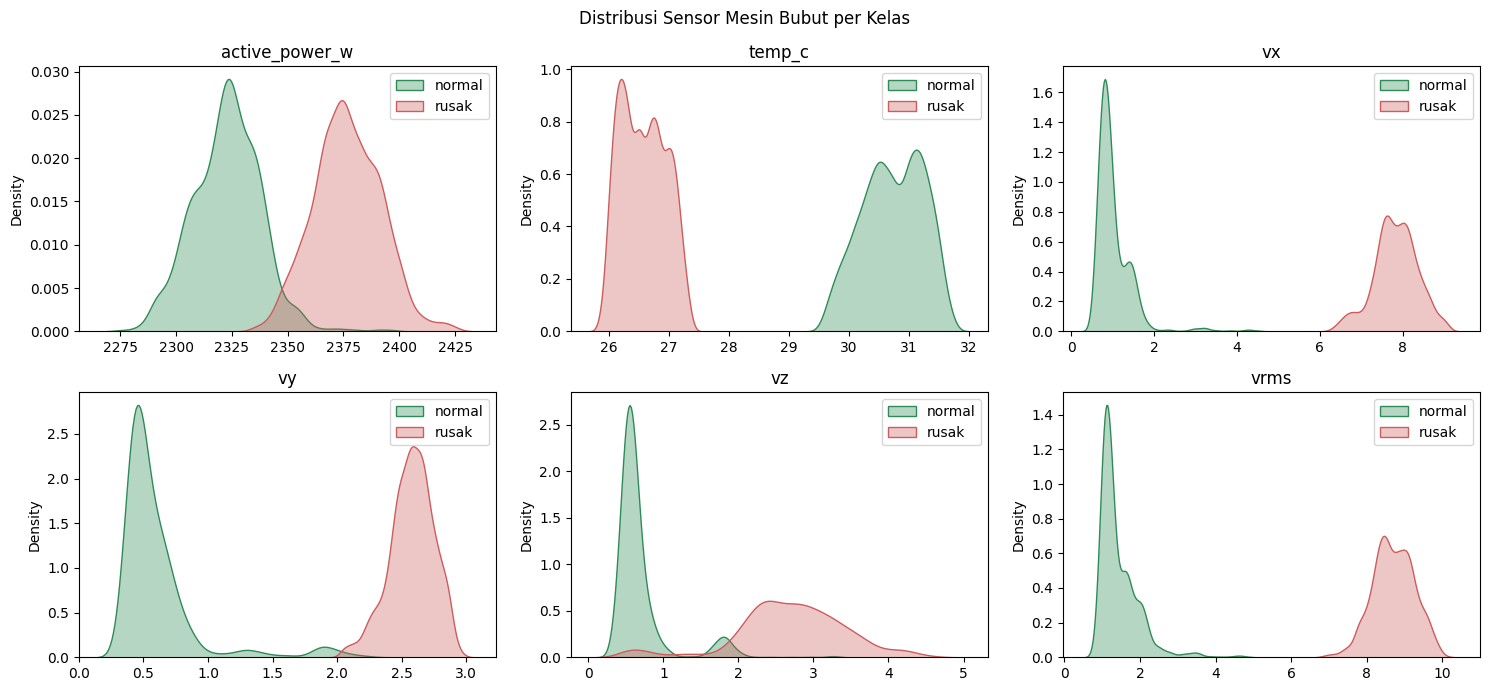

In [7]:
# Sebaran tiap sensor per kelas — untuk melihat sensor mana yang paling
# memisahkan kondisi normal dan rusak.
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.ravel(), feature_columns):
    for label, color in [("normal", "seagreen"), ("rusak", "indianred")]:
        sns.kdeplot(
            data.loc[data["status"] == label, col],
            ax=ax, label=label, color=color, fill=True, alpha=0.35,
        )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.legend()
fig.suptitle("Distribusi Sensor Mesin Bubut per Kelas")
plt.tight_layout()
plt.show()

## Pemisahan Data per `id_induk`

Fungsi di bawah memisahkan data pada level **induk**, bukan level baris. Semua
baris sintetis turunan satu induk pasti berada di split yang sama, sehingga
model tidak pernah diuji dengan variasi data yang induknya sudah pernah dilihat
saat latihan. Proporsi kelas tetap dijaga (`stratify` pada label induk).

In [8]:
def split_by_parent(df, label_col="status", group_col="id_induk",
                    test_size=0.2, random_state=RANDOM_STATE):
    """Pisahkan df jadi dua bagian tanpa memecah satu id_induk ke dua sisi."""
    parents = df.groupby(group_col)[label_col].first()
    parent_train, parent_test = train_test_split(
        parents.index, test_size=test_size,
        stratify=parents.values, random_state=random_state,
    )
    left = df[df[group_col].isin(parent_train)]
    right = df[df[group_col].isin(parent_test)]
    return left, right


trainval_df, test_df = split_by_parent(data, test_size=0.2)
train_df, val_df = split_by_parent(trainval_df, test_size=0.2)

for nama, bagian in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{nama:6s}: {len(bagian):5d} baris | "
          f"{bagian['id_induk'].nunique():3d} induk | "
          f"{bagian['status'].value_counts().to_dict()}")

# Pastikan benar-benar tidak ada induk yang bocor antar split
induk_train, induk_val, induk_test = (set(b["id_induk"]) for b in (train_df, val_df, test_df))
print("\nIrisan induk train-val :", len(induk_train & induk_val))
print("Irisan induk train-test:", len(induk_train & induk_test))
print("Irisan induk val-test  :", len(induk_val & induk_test))

Train :  3893 baris | 268 induk | {'rusak': 1964, 'normal': 1929}
Val   :   934 baris |  68 induk | {'rusak': 467, 'normal': 467}
Test  :  1173 baris |  84 induk | {'normal': 604, 'rusak': 569}

Irisan induk train-val : 0
Irisan induk train-test: 0
Irisan induk val-test  : 0



  MODEL: STATUS

Train : {1: 1964, 0: 1929}
Val   : {1: 467, 0: 467}
Test  : {0: 604, 1: 569}
After SMOTE: {0: 1964, 1: 1964}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_features (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

...

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 2.1337e-05 - val_accuracy: 1.0000 - val_loss: 1.4310e-13


Epoch 150/150


 1/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 1.0000 - loss: 5.9478e-07

60/62 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step - accuracy: 1.0000 - loss: 8.4700e-06

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 5.3756e-06 - val_accuracy: 1.0000 - val_loss: 1.4903e-13


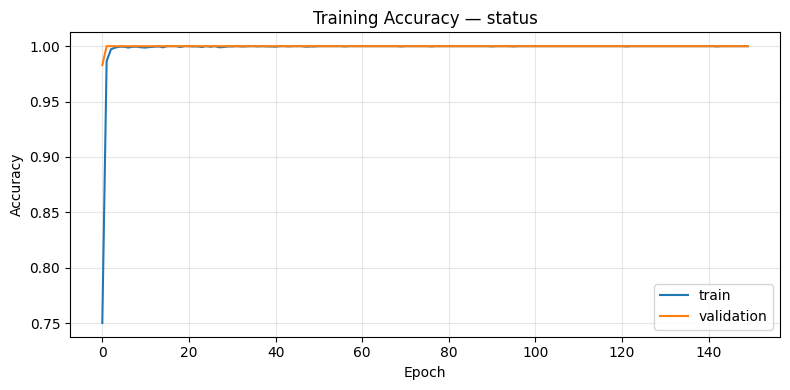


--- Metrics ---
  accuracy: 1.0000
  balanced_accuracy: 1.0000
  f1_fault: 1.0000
  roc_auc: 1.0000
              precision    recall  f1-score   support

          Ok       1.00      1.00      1.00       604
       Fault       1.00      1.00      1.00       569

    accuracy                           1.00      1173
   macro avg       1.00      1.00      1.00      1173
weighted avg       1.00      1.00      1.00      1173

--- Hanya baris 'asli' di test set (n=84) ---
  accuracy : 1.0000
  f1_fault : 1.0000


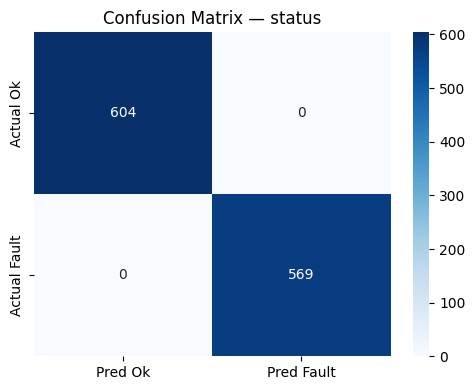

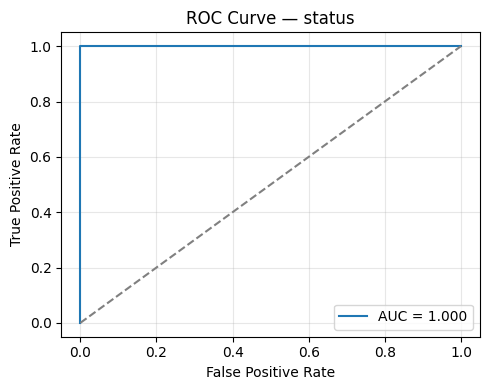

  0%|          | 0/50 [00:00<?, ?it/s]

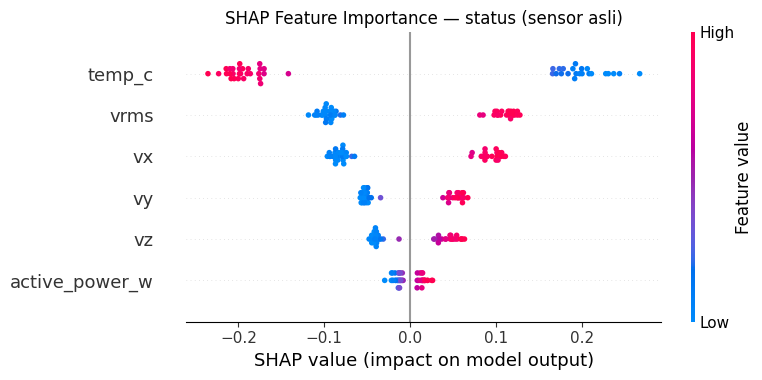

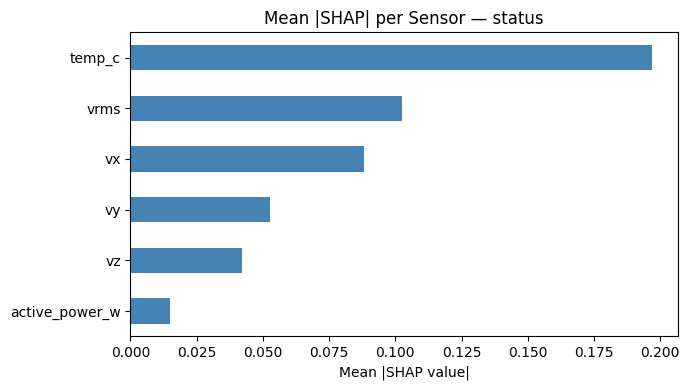

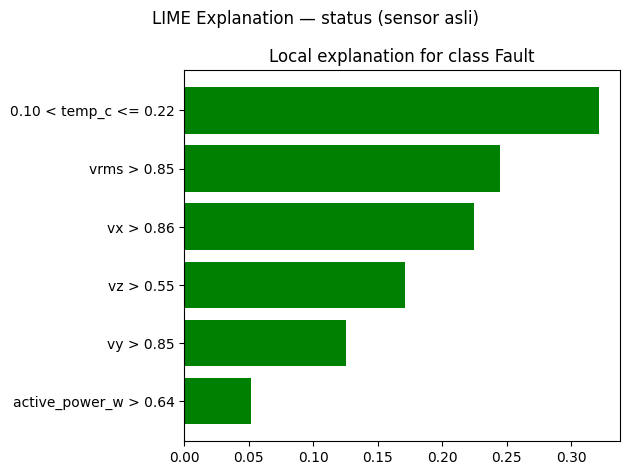

Saved: models/hybrid_model_status.pkl


In [9]:
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

all_metrics = {}

for target_column, config in TARGETS.items():
    print(f"\n{'='*60}")
    print(f"  MODEL: {target_column.upper()}")
    print(f"{'='*60}\n")

    label_map = config["label_map"]
    class_names = config["class_names"]

    # --- Split (per id_induk, lihat sel sebelumnya) ---
    X_train_raw = train_df[feature_columns].copy()
    X_val_raw   = val_df[feature_columns].copy()
    X_test_raw  = test_df[feature_columns].copy()
    y_train = train_df[target_column].map(label_map)
    y_val   = val_df[target_column].map(label_map)
    y_test  = test_df[target_column].map(label_map)

    print(f"Train : {y_train.value_counts().to_dict()}")
    print(f"Val   : {y_val.value_counts().to_dict()}")
    print(f"Test  : {y_test.value_counts().to_dict()}")

    # --- Scale ---
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_val   = scaler.transform(X_val_raw)
    X_test  = scaler.transform(X_test_raw)

    # --- SMOTE ---
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print(f"After SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")

    # --- DNN ---
    tf.random.set_seed(RANDOM_STATE)
    model = Sequential([
        Input(shape=(X_train_res.shape[1],)),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(16, activation="relu", name="latent_features"),
        Dropout(0.3),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    model.summary()

    early_stop = EarlyStopping(
        monitor="val_loss", patience=20, restore_best_weights=True
    )
    history = model.fit(
        X_train_res, y_train_res,
        epochs=150,
        batch_size=64,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        shuffle=True,
        verbose=1,
    )

    # Training history
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="validation")
    plt.title(f"Training Accuracy — {target_column}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Feature extractor ---
    feature_extractor = tf.keras.Model(
        inputs=model.inputs,
        outputs=model.get_layer("latent_features").output,
    )
    train_features_res = feature_extractor.predict(X_train_res, verbose=0)
    val_features       = feature_extractor.predict(X_val, verbose=0)
    test_features      = feature_extractor.predict(X_test, verbose=0)

    # --- SVM ---
    svm = SVC(
        kernel="rbf", C=10, gamma="scale",
        class_weight="balanced", probability=True,
        random_state=RANDOM_STATE,
    )
    svm.fit(train_features_res, y_train_res)

    # --- Evaluation ---
    pred   = svm.predict(test_features)
    y_prob = svm.predict_proba(test_features)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "f1_fault": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
    }
    all_metrics[target_column] = metrics

    print("\n--- Metrics ---")
    for name, value in metrics.items():
        print(f"  {name}: {value:.4f}")
    print(classification_report(y_test, pred, target_names=class_names))

    # Metrik khusus baris pengukuran asli di test set — memastikan performa
    # tidak hanya bagus pada baris hasil augmentasi.
    mask_asli = (test_df["sumber"] == "asli").to_numpy()
    if mask_asli.sum() > 0:
        print(f"--- Hanya baris 'asli' di test set (n={int(mask_asli.sum())}) ---")
        print(f"  accuracy : {accuracy_score(y_test[mask_asli], pred[mask_asli]):.4f}")
        print(f"  f1_fault : {f1_score(y_test[mask_asli], pred[mask_asli]):.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=[f"Pred {c}" for c in class_names],
        yticklabels=[f"Actual {c}" for c in class_names],
    )
    plt.title(f"Confusion Matrix — {target_column}")
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title(f"ROC Curve — {target_column}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- SHAP (pipeline end-to-end: sensor asli -> DNN -> SVM) ---
    def pipeline_predict_proba(X_sensor):
        latent = feature_extractor.predict(X_sensor, verbose=0)
        return svm.predict_proba(latent)

    shap_background = shap.sample(X_train, 100, random_state=RANDOM_STATE)
    shap_explainer = shap.KernelExplainer(
        pipeline_predict_proba,
        shap_background,
    )
    shap_values = shap_explainer.shap_values(X_test[:50])
    # shap_values shape: (n_samples, n_features, n_classes) -> ambil kelas fault (index 1)
    sv_arr = np.array(shap_values)
    if sv_arr.ndim == 3:
        sv_fault = sv_arr[:, :, 1]   # (n_samples, n_features) untuk kelas fault
    elif isinstance(shap_values, list):
        sv_fault = np.array(shap_values[1])
    else:
        sv_fault = sv_arr
    shap.summary_plot(sv_fault, X_test[:50], feature_names=feature_columns, show=False)
    plt.title(f"SHAP Feature Importance — {target_column} (sensor asli)")
    plt.tight_layout()
    plt.show()

    # Bar plot rata-rata |SHAP| per sensor
    mean_shap = np.abs(sv_fault).mean(axis=0)
    shap_df = pd.Series(mean_shap, index=feature_columns).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(7, 4))
    shap_df.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"Mean |SHAP| per Sensor — {target_column}")
    ax.set_xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.show()

    # --- LIME (pipeline end-to-end: sensor asli -> DNN -> SVM) ---
    lime_explainer = LimeTabularExplainer(
        X_train,
        feature_names=feature_columns,
        class_names=class_names,
        mode="classification",
        discretize_continuous=True,
        random_state=RANDOM_STATE,
    )
    lime_exp = lime_explainer.explain_instance(
        X_test[0], pipeline_predict_proba, num_features=len(feature_columns)
    )
    fig = lime_exp.as_pyplot_figure()
    fig.suptitle(f"LIME Explanation — {target_column} (sensor asli)")
    plt.tight_layout()
    plt.show()

    # --- Save ---
    model.save(models_dir / f"dnn_{target_column}.keras")
    feature_extractor.save(models_dir / f"dnn_extractor_{target_column}.keras")
    joblib.dump(
        {
            "scaler": scaler,
            "svm": svm,
            "feature_columns": feature_columns,
            "target_column": target_column,
            "label_mapping": label_map,
            "class_names": class_names,
            "metrics": metrics,
        },
        models_dir / f"hybrid_model_{target_column}.pkl",
    )
    print(f"Saved: models/hybrid_model_{target_column}.pkl")


  RINGKASAN METRICS — STATUS
  Accuracy        : 1.0000
  Balanced Acc    : 1.0000
  F1 Fault        : 1.0000
  ROC-AUC         : 1.0000


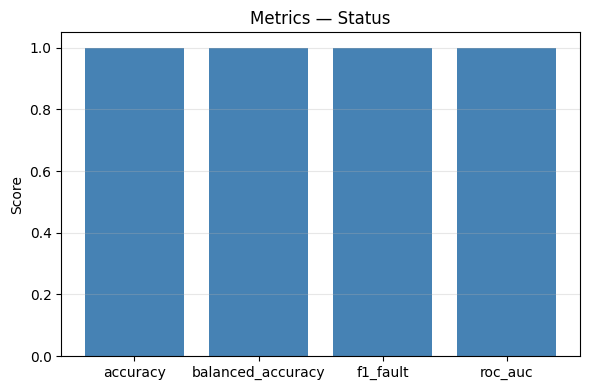

In [10]:
target_column = "status"
metrics = all_metrics[target_column]

print("\n" + "="*60)
print("  RINGKASAN METRICS — STATUS")
print("="*60)

print(f"  Accuracy        : {metrics['accuracy']:.4f}")
print(f"  Balanced Acc    : {metrics['balanced_accuracy']:.4f}")
print(f"  F1 Fault        : {metrics['f1_fault']:.4f}")
print(f"  ROC-AUC         : {metrics['roc_auc']:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(metrics.keys(), metrics.values(), color="steelblue")
ax.set_title("Metrics — Status")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Catatan Penting: Kenapa Metriknya Sempurna?

Semua metrik menyentuh 1,00. Ini **bukan** karena arsitektur DNN-SVM luar biasa,
melainkan karena karakter datasetnya: pada dataset ini kondisi `normal` dan
`rusak` terpisah bersih (ada jarak kosong, tanpa irisan sama sekali) di sensor
suhu, getaran sumbu X, dan getaran resultan. Sel di bawah membuktikannya dengan
membandingkan rentang nilai tiap sensor per kelas.

Konsekuensinya untuk sistem CMMS:

- Klasifikasi normal/rusak untuk mesin bubut memang mudah — model sesederhana
  ambang batas pun bisa. Nilai tambah pipeline ini ada pada keseragaman
  antarmuka dengan mesin lain (satu format bundle, satu jalur inferensi) dan
  pada penjelasan SHAP/LIME-nya, bukan pada angka akurasinya.
- Probabilitas keluaran model hampir selalu menempel di 0 atau 1, sehingga
  tingkat risiko menengah (*low*/*medium*/*high*) baru muncul di pita transisi
  yang sempit. Hal ini dipakai saat menyusun preset simulator di bagian akhir.
- Metrik setinggi ini tidak boleh diklaim sebagai performa di lapangan. Data
  latih berasal dari 420 pengukuran asli yang diperbanyak jadi 6.000 baris;
  variasi kondisi nyata (beban benda kerja, jenis pahat, keausan bertahap)
  belum terwakili. Menambah data asli — terutama kondisi peralihan menuju
  rusak — adalah kelanjutan yang paling berdampak.

Rentang nilai tiap sensor per kelas (cek irisan):

                normal_min  normal_max  rusak_min  rusak_max  beririsan
sensor                                                                 
active_power_w    2274.090    2397.220   2334.530   2425.610       True
temp_c              29.600      31.700     25.900     27.300      False
vx                   0.533       4.563      6.245      9.096      False
vy                   0.340       2.282      2.039      2.980       True
vz                   0.372       3.314      0.466      4.626       True
vrms                 0.785       4.912      6.827     10.166      False

Sensor yang memisahkan kedua kelas tanpa irisan: ['temp_c', 'vx', 'vrms']


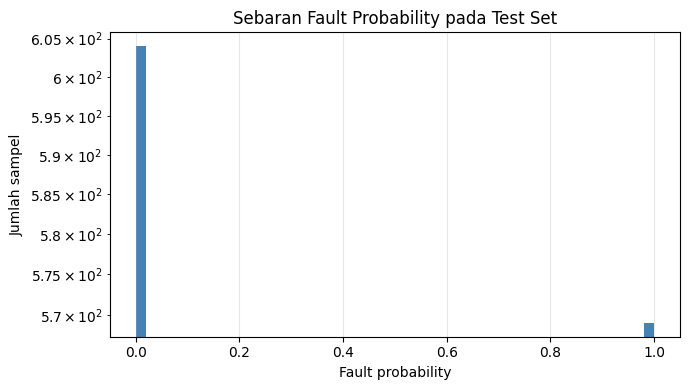

Sampel dengan probabilitas di antara 0,01 dan 0,99: 0 dari 1173


In [11]:
print("Rentang nilai tiap sensor per kelas (cek irisan):\n")
ringkas = []
for col in feature_columns:
    normal = data.loc[data["status"] == "normal", col]
    rusak  = data.loc[data["status"] == "rusak", col]
    beririsan = not (normal.max() < rusak.min() or rusak.max() < normal.min())
    ringkas.append({
        "sensor": col,
        "normal_min": round(normal.min(), 3), "normal_max": round(normal.max(), 3),
        "rusak_min": round(rusak.min(), 3),   "rusak_max": round(rusak.max(), 3),
        "beririsan": beririsan,
    })
ringkas_df = pd.DataFrame(ringkas).set_index("sensor")
print(ringkas_df.to_string())

pemisah = ringkas_df.index[~ringkas_df["beririsan"]].tolist()
print(f"\nSensor yang memisahkan kedua kelas tanpa irisan: {pemisah}")

# Sebaran probabilitas fault pada seluruh test set — memperlihatkan bahwa
# keluaran model menumpuk di dua ujung (0 dan 1), nyaris tanpa nilai tengah.
plt.figure(figsize=(7, 4))
plt.hist(y_prob, bins=50, color="steelblue")
plt.title("Sebaran Fault Probability pada Test Set")
plt.xlabel("Fault probability")
plt.ylabel("Jumlah sampel")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

tengah = int(((y_prob > 0.01) & (y_prob < 0.99)).sum())
print(f"Sampel dengan probabilitas di antara 0,01 dan 0,99: {tengah} dari {len(y_prob)}")

## Uji Coba Inferensi

Memuat kembali artefak yang tersimpan di `models/` dan menjalankan prediksi pada beberapa sampel sensor — memastikan bundle siap dipakai backend (`app/predictors/generic.py` lewat entri `BBT-001` di `app/ml_registry.py`).

In [12]:
bundle = joblib.load(models_dir / "hybrid_model_status.pkl")
extractor = tf.keras.models.load_model(models_dir / "dnn_extractor_status.keras")

def predict_bubut(sample: dict):
    """Prediksi satu pembacaan sensor mesin bubut (dict key = feature_columns)."""
    x = np.array([[sample[c] for c in bundle["feature_columns"]]], dtype=float)
    latent = extractor.predict(bundle["scaler"].transform(x), verbose=0)
    proba = bundle["svm"].predict_proba(latent)[0]
    fault_prob = float(proba[1])
    return {
        "prediction": bundle["class_names"][int(fault_prob >= 0.5)],
        "fault_probability": round(fault_prob, 4),
        "health_score": round(1 - fault_prob, 4),
    }

# Ambil satu contoh nyata (sumber = asli) dari tiap kelas
asli = data[data["sumber"] == "asli"]
samples = {
    "normal": asli[asli["status"] == "normal"].iloc[0],
    "rusak":  asli[asli["status"] == "rusak"].iloc[0],
}
for actual, row in samples.items():
    sample = {c: float(row[c]) for c in feature_columns}
    print(f"Actual: {actual:7s} -> {predict_bubut(sample)}")

Actual: normal  -> {'prediction': 'Ok', 'fault_probability': 0.0004, 'health_score': 0.9996}
Actual: rusak   -> {'prediction': 'Fault', 'fault_probability': 1.0, 'health_score': 0.0}


## Preset Simulator

Front-end menampilkan 5 tingkat risiko (*very low* → *critical*), jadi simulator
perlu contoh nilai sensor untuk masing-masing tingkat. Preset **normal** dan
**kritis** diambil dari baris pengukuran asli. Tiga tingkat di antaranya tidak
bisa diambil dari dataset — seperti ditunjukkan di atas, tidak ada satu pun baris
yang probabilitasnya berada di antara 0,01 dan 0,99.

Karena itu tingkat menengah dibangkitkan dengan **menginterpolasi** dari
pembacaan normal menuju pembacaan rusak: getaran dinaikkan bertahap sambil suhu
dan daya bergeser mengikuti, dan `vrms` dihitung ulang sebagai resultan
`vx`/`vy`/`vz` agar nilainya tetap konsisten secara fisis. Titik-titik ini
berada di pita transisi yang memang tidak terwakili di dataset — dipakai untuk
mendemonstrasikan tampilan tingkat risiko di dashboard, bukan sebagai klaim
bahwa mesin nyata pernah terukur pada nilai tersebut.

Preset siap tempel ke Simulasi/Version 2/simulasi-input data/config.py

# normal — fault probability 0.0%
"data": {"active_power_w": 2274.090, "temp_c": 30.600, "vx": 2.398, "vy": 0.775, "vz": 0.482, "vrms": 2.566},
# bubut_low — fault probability 20.4%
"data": {"active_power_w": 2326.204, "temp_c": 28.929, "vx": 5.093, "vy": 1.740, "vz": 1.746, "vrms": 5.659},
# bubut_medium — fault probability 39.5%
"data": {"active_power_w": 2328.933, "temp_c": 28.841, "vx": 5.235, "vy": 1.791, "vz": 1.812, "vrms": 5.822},
# bubut_high — fault probability 64.5%
"data": {"active_power_w": 2331.934, "temp_c": 28.745, "vx": 5.390, "vy": 1.846, "vz": 1.885, "vrms": 6.001},


# bubut_critical — fault probability 100.0%
"data": {"active_power_w": 2383.230, "temp_c": 27.100, "vx": 8.043, "vy": 2.796, "vz": 3.129, "vrms": 9.072},


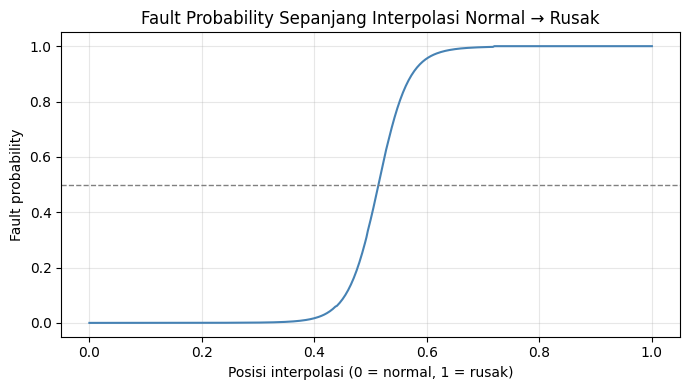

In [13]:
def fault_probability(rows):
    """Probabilitas fault untuk sekumpulan baris sensor (urutan = feature_columns)."""
    X = pd.DataFrame(np.asarray(rows, dtype=float), columns=feature_columns)
    latent = extractor.predict(bundle["scaler"].transform(X), verbose=0)
    return bundle["svm"].predict_proba(latent)[:, 1]


asli = data[data["sumber"] == "asli"]
titik_normal = asli[asli["status"] == "normal"].iloc[0][feature_columns].astype(float).to_numpy()
titik_rusak  = asli[asli["status"] == "rusak"].iloc[0][feature_columns].astype(float).to_numpy()

# Jalur interpolasi normal -> rusak, dengan vrms dihitung ulang sebagai resultan
idx_v = [feature_columns.index(c) for c in ("vx", "vy", "vz")]
idx_vrms = feature_columns.index("vrms")

alphas = np.linspace(0, 1, 401)
jalur = []
for a in alphas:
    titik = titik_normal + a * (titik_rusak - titik_normal)
    titik[idx_vrms] = np.sqrt(sum(titik[i] ** 2 for i in idx_v))
    jalur.append(titik)
prob_jalur = fault_probability(jalur)

TINGKAT = [
    ("normal",         None),   # pakai baris asli
    ("bubut_low",      0.20),
    ("bubut_medium",   0.40),
    ("bubut_high",     0.65),
    ("bubut_critical", None),   # pakai baris asli
]

print("Preset siap tempel ke Simulasi/Version 2/simulasi-input data/config.py\n")
for nama, target in TINGKAT:
    if nama == "normal":
        titik, p = titik_normal, fault_probability([titik_normal])[0]
    elif nama == "bubut_critical":
        titik, p = titik_rusak, fault_probability([titik_rusak])[0]
    else:
        i = int(np.abs(prob_jalur - target).argmin())
        titik, p = jalur[i], prob_jalur[i]
    nilai = ", ".join(f'"{c}": {titik[k]:.3f}' for k, c in enumerate(feature_columns))
    print(f'# {nama} — fault probability {p*100:.1f}%')
    print(f'"data": {{{nilai}}},')

# Kurva probabilitas sepanjang jalur interpolasi — memperlihatkan betapa
# sempitnya pita transisi antara normal dan rusak.
plt.figure(figsize=(7, 4))
plt.plot(alphas, prob_jalur, color="steelblue")
plt.axhline(0.5, linestyle="--", color="gray", linewidth=1)
plt.title("Fault Probability Sepanjang Interpolasi Normal → Rusak")
plt.xlabel("Posisi interpolasi (0 = normal, 1 = rusak)")
plt.ylabel("Fault probability")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()